# A Jupyter Notebook to Generate Performance Boxplots and Feature Importance Calculations from WandB Runs
This notebook is designed to analyze performance metrics and feature importance from WandB runs. It includes sections for importing libraries, fetching data, generating performance boxplots, and calculating feature importance.

This notebook is essentially a pared-down, cleaned-up version of `stability_and_performance_analysis.ipynb`.

## Import Required Libraries
Import necessary libraries such as `wandb`, `pandas`, `numpy`, `matplotlib`, and `seaborn`.

In [1]:
# Import Required Libraries
import logging
import os
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import wandb


## Setup Logging and Configuration
Set up logging and define configurations such as WandB project name, sweep ID, and directories for saving results.

In [4]:
# Setup Logging and Configuration
logging.basicConfig(
    format="%(asctime)s %(levelname)-8s [%(name)s] %(message)s",
    level=logging.INFO,
    datefmt="%Y-%m-%d %H:%M:%S",
    force=True,
)
logger = logging.getLogger(__name__)

# Define WandB project and sweep details
PROJECT_NAME = "millergw/prostate_met_status"
GROUP_NAME = "perturbed_somatic_mut_001"
SWEEP_ID = "nzb5fy1p" 
# Define directories for saving results
FIGDIR = f"../figures/{SWEEP_ID}/"
RESULTS_DIR = f"../results/{SWEEP_ID}/"

# PROJECT_NAME = "millergw/prostate_met_status"
# GROUP_NAME = "pnet_somatic_and_germline_exp_004"
# SWEEP_ID = "rv4lm363" # germline filtered for pathogenicity
# # Define directories for saving results
# FIGDIR = f"../figures/{GROUP_NAME}/"
# RESULTS_DIR = f"../results/{GROUP_NAME}/"

# GROUP_NAME = "pnet_somatic_and_germline_exp_003"
# SWEEP_ID = "cmlmrw2s" # germline not filtered for pathogenicity
# # Define directories for saving results
# FIGDIR = f"../figures/{SWEEP_ID}/"
# RESULTS_DIR = f"../results/{SWEEP_ID}/"



# make directory if it doesn't exist
os.makedirs(os.path.join(FIGDIR), exist_ok=True)

In [ ]:
# Temporary: add parameters

import re

# Initialize the W&B API
api = wandb.Api()

PROJECT_NAME = "millergw/prostate_met_status"
SWEEP_ID = "nzb5fy1p" 

# Fetch all runs in the sweep
sweep = api.sweep(f"{PROJECT_NAME}/{SWEEP_ID}")
runs = sweep.runs

# Iterate through the runs
for run in runs:
    config = run.config

    # Check if the keys are missing
    if "perturbed_gene" not in config or "odds_ratio" not in config or "control_frequency" not in config:
        perturbation_suffix = config.get("perturbation_suffix")
        if not perturbation_suffix:
            print(f"Run {run.id} does not have a perturbation_suffix. Skipping.")
            continue

        # Parse the perturbation_suffix
        match = re.match(
            r"gene-(?P<gene>[A-Za-z0-9]+)_OR-(?P<odds_ratio>[0-9p]+)_ctrlFreq-(?P<control_freq>[0-9p]+)",
            perturbation_suffix,
        )
        if match:
            perturbed_gene = match.group("gene")
            odds_ratio = float(match.group("odds_ratio").replace("p", "."))
            control_frequency = float(match.group("control_freq").replace("p", "."))

            # Update the run's config
            run.config["perturbed_gene"] = perturbed_gene
            run.config["odds_ratio"] = odds_ratio
            run.config["control_frequency"] = control_frequency
            run.update()
            print(f"Updated run {run.id} with perturbed_gene={perturbed_gene}, odds_ratio={odds_ratio}, control_frequency={control_frequency}.")
        else:
            print(f"Run {run.id} has an unparsable perturbation_suffix: {perturbation_suffix}. Skipping.")
    else:
        print(f"Run {run.id} already has the required keys. Skipping.")

Run 12tbvfl5 already has the required keys. Skipping.
Run 2cig5ij7 already has the required keys. Skipping.
Run kgizhcll already has the required keys. Skipping.
Run gtur9vob already has the required keys. Skipping.
Run j5wamhvt already has the required keys. Skipping.
Run cxqmc96q already has the required keys. Skipping.
Run by8cxuqr already has the required keys. Skipping.
Run eysl2vke already has the required keys. Skipping.
Run wfhwsl2f already has the required keys. Skipping.
Run mfw4b29h already has the required keys. Skipping.
Run xml17ou7 already has the required keys. Skipping.
Run bldifv63 already has the required keys. Skipping.
Run 2l1lpig2 already has the required keys. Skipping.
Run 6u9a0631 already has the required keys. Skipping.
Run 1xns41kn already has the required keys. Skipping.
Run rmf42cqf already has the required keys. Skipping.
Run qizjvkj9 already has the required keys. Skipping.
Run ravwe9pn already has the required keys. Skipping.
Run khz33dd2 already has the

## Fetch WandB Runs and Performance Metrics (grouped by model_type, OR, and control_frequency)
Use the WandB API to fetch runs and extract performance metrics grouped by `model_type`, `odds_ratio`, and 'control_frequency' for purposes of assessing the 'power curve' of the model. Store the results in a DataFrame.

In [5]:
df

,model_type,odds_ratio,control_frequency,roc_auc,balanced_acc,avg_precision
0,rf,10.0,0.1,0.962245,0.969388,0.905118
1,rf,10.0,0.1,0.965816,0.959184,0.926449
2,rf,10.0,0.1,0.961735,0.946684,0.921841
3,rf,10.0,0.1,0.960204,0.959184,0.926756
4,rf,10.0,0.1,0.962755,0.936480,0.929664
...,...,...,...,...,...,...
235,pnet,1.1,0.2,0.512500,0.500000,0.472753
236,pnet,1.0,0.2,0.564286,0.500000,0.537175
237,pnet,1.0,0.2,0.470408,0.500000,0.463734
238,pnet,1.0,0.2,0.528571,0.500000,0.489915


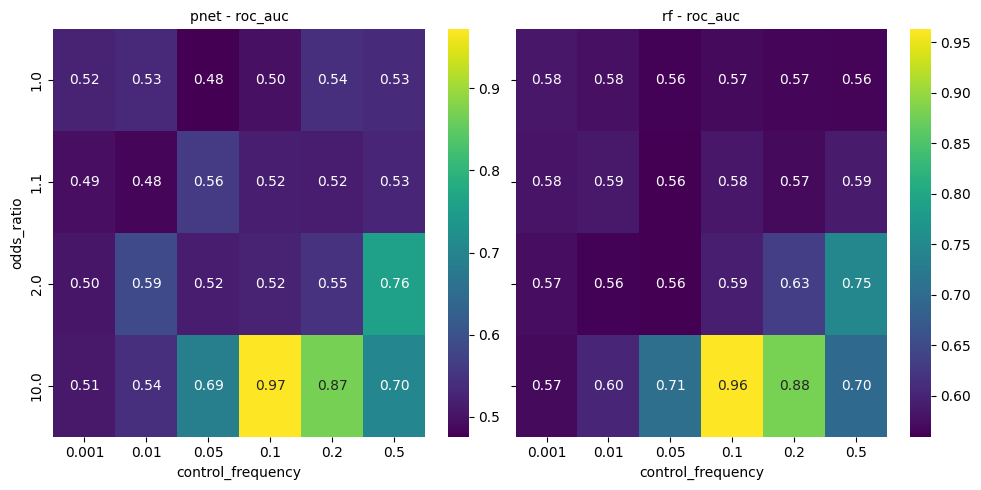

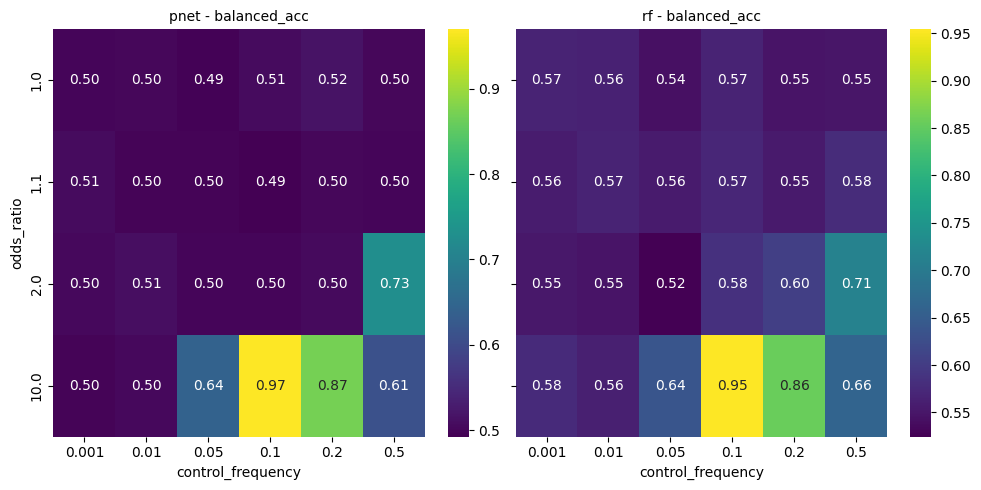

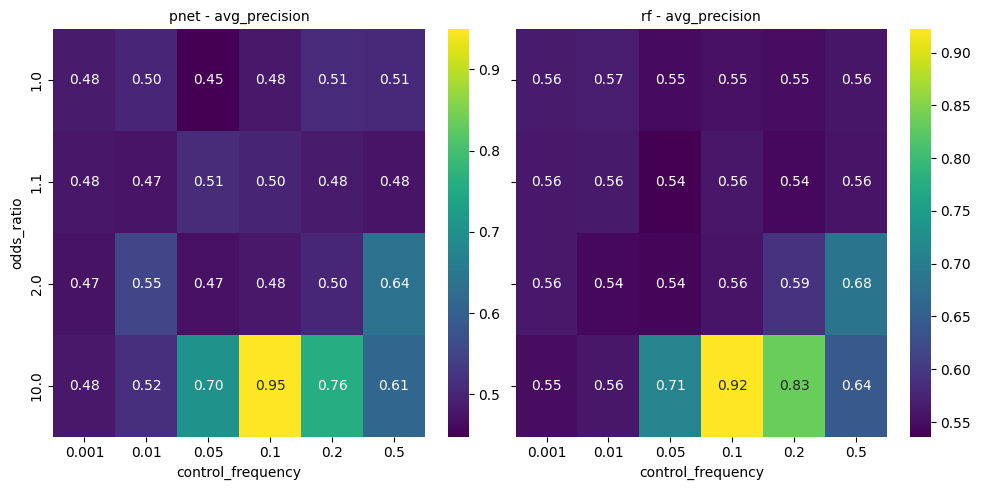

In [ ]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize W&B API
api = wandb.Api()
PROJECT_NAME = "millergw/prostate_met_status"
SWEEP_IDS = ["nzb5fy1p", "ahjm7e9e"] # these sweeps used the full number of features, around 4.8k genes
SWEEP_IDS = ["0kgc2kob", "m685u4y1", "fdad53f2"] # using a variety of n_features values

# Collect runs from both sweeps
all_records = []

for sweep_id in SWEEP_IDS:
    sweep = api.sweep(f"{PROJECT_NAME}/{sweep_id}")
    for run in sweep.runs:
        config = run.config
        summary = run.summary
        all_records.append({
            "model_type": config.get("model_type"),
            "n_features": config.get("n_features"),
            "odds_ratio": float(config.get("odds_ratio")),
            "control_frequency": float(config.get("control_frequency")),
            "roc_auc": summary.get("validation_roc_auc_score"),
            "balanced_acc": summary.get("validation_balanced_acc"),
            "avg_precision": summary.get("validation_average_precision_score"),
        })

# Convert to a single DataFrame
df = pd.DataFrame(all_records)

# Average over seeds
df_avg = df.groupby(["model_type", "n_features", "odds_ratio", "control_frequency"], as_index=False).mean()

# Plot heatmaps for each metric and model_type
metrics = ["roc_auc", "balanced_acc", "avg_precision"]
for metric in metrics:
    g = sns.FacetGrid(df_avg, col="model_type", height=5, aspect=1)
    g.map_dataframe(
        lambda data, color: sns.heatmap(
            data.pivot(index="odds_ratio", columns="control_frequency", values=metric),
            cmap="viridis", annot=True, fmt=".2f", cbar=True
        )
    )
    g.set_titles(col_template="{col_name} - " + metric)
    g.set_axis_labels("control_frequency", "odds_ratio")
    plt.tight_layout()
    plt.show()


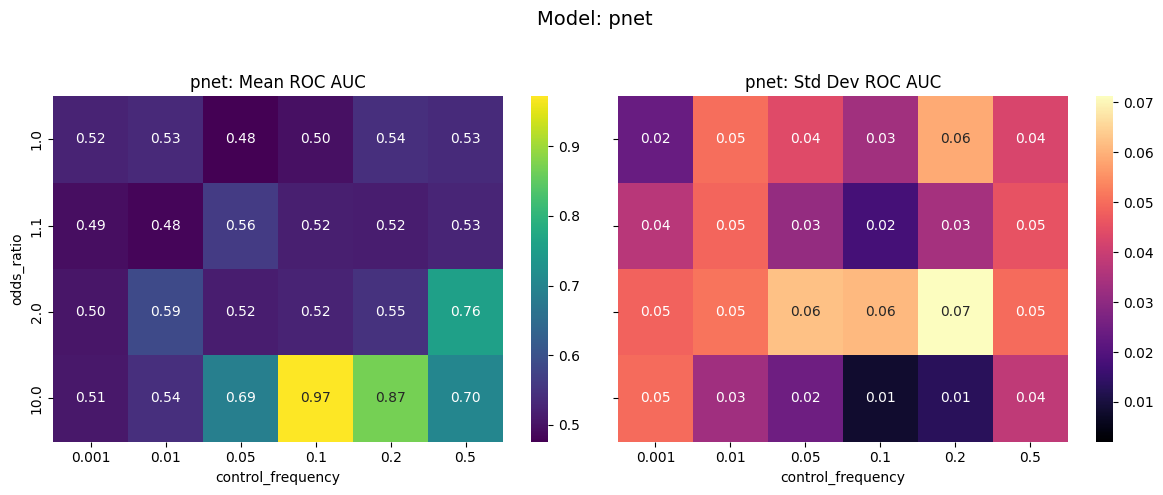

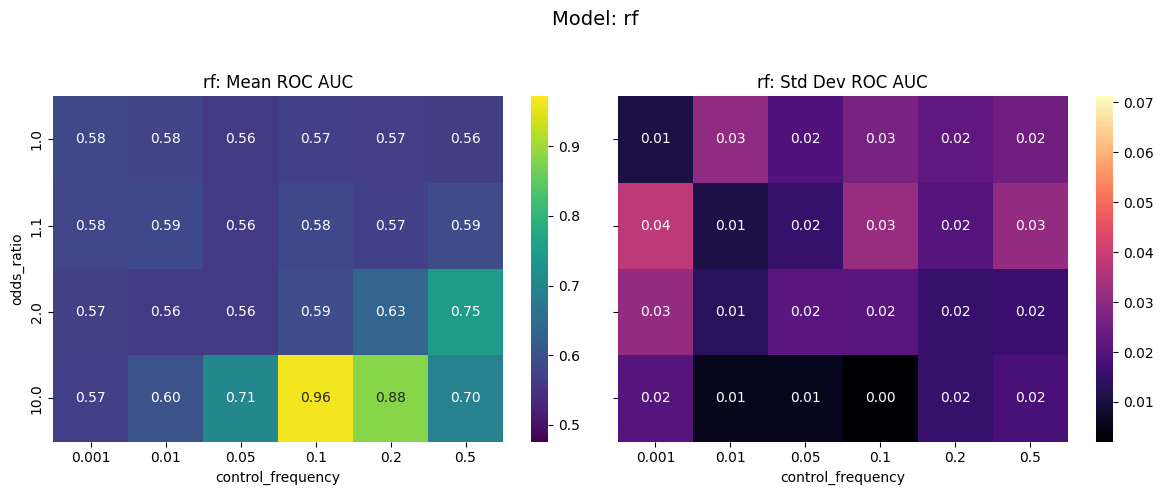

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute mean and std
agg_df = df.groupby(["model_type", "odds_ratio", "control_frequency"]).agg(
    roc_auc_mean=("roc_auc", "mean"),
    roc_auc_std=("roc_auc", "std")
).reset_index()

# Get global vmin/vmax for mean and std across all models
vmin_mean = agg_df["roc_auc_mean"].min()
vmax_mean = agg_df["roc_auc_mean"].max()

vmin_std = agg_df["roc_auc_std"].min()
vmax_std = agg_df["roc_auc_std"].max()

# Make sure sorting is consistent
agg_df["odds_ratio"] = agg_df["odds_ratio"].astype(float)
agg_df["control_frequency"] = agg_df["control_frequency"].astype(float)
agg_df.sort_values(["odds_ratio", "control_frequency"], inplace=True)

# Plot heatmaps side by side for each model_type
for model in agg_df["model_type"].unique():
    data_model = agg_df[agg_df["model_type"] == model]

    mean_pivot = data_model.pivot(index="odds_ratio", columns="control_frequency", values="roc_auc_mean")
    std_pivot = data_model.pivot(index="odds_ratio", columns="control_frequency", values="roc_auc_std")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    sns.heatmap(mean_pivot, ax=axes[0], cmap="viridis", annot=True, fmt=".2f",
                vmin=vmin_mean, vmax=vmax_mean, cbar=True)
    axes[0].set_title(f"{model}: Mean ROC AUC")
    axes[0].set_xlabel("control_frequency")
    axes[0].set_ylabel("odds_ratio")

    sns.heatmap(std_pivot, ax=axes[1], cmap="magma", annot=True, fmt=".2f",
                vmin=vmin_std, vmax=vmax_std, cbar=True)
    axes[1].set_title(f"{model}: Std Dev ROC AUC")
    axes[1].set_xlabel("control_frequency")
    axes[1].set_ylabel("")

    plt.suptitle(f"Model: {model}", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


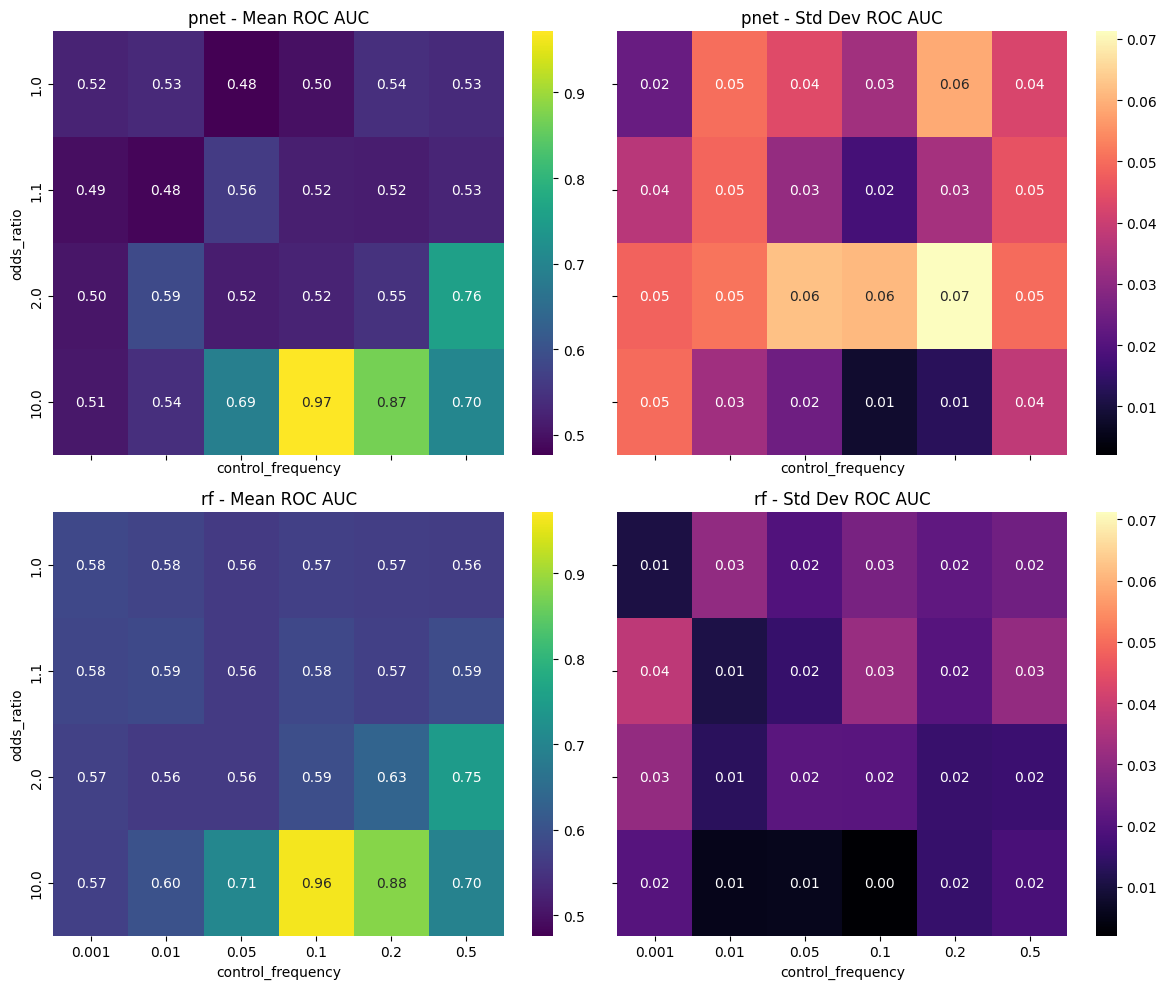

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Aggregate across seeds
agg_df = df.groupby(["model_type", "odds_ratio", "control_frequency"]).agg(
    roc_auc_mean=("roc_auc", "mean"),
    roc_auc_std=("roc_auc", "std")
).reset_index()

# Ensure numeric sort order
agg_df["odds_ratio"] = agg_df["odds_ratio"].astype(float)
agg_df["control_frequency"] = agg_df["control_frequency"].astype(float)
agg_df.sort_values(["odds_ratio", "control_frequency"], inplace=True)

# Get global color scales
vmin_mean = agg_df["roc_auc_mean"].min()
vmax_mean = agg_df["roc_auc_mean"].max()
vmin_std = agg_df["roc_auc_std"].min()
vmax_std = agg_df["roc_auc_std"].max()

# Create a subplot grid: rows = model_type, cols = [mean, std]
model_types = agg_df["model_type"].unique()
fig, axes = plt.subplots(len(model_types), 2, figsize=(12, 5 * len(model_types)), sharex=True, sharey=True)

# If only one model type, fix axes to be 2D array
if len(model_types) == 1:
    axes = [axes]

for i, model in enumerate(model_types):
    data_model = agg_df[agg_df["model_type"] == model]

    mean_pivot = data_model.pivot(index="odds_ratio", columns="control_frequency", values="roc_auc_mean")
    std_pivot = data_model.pivot(index="odds_ratio", columns="control_frequency", values="roc_auc_std")

    sns.heatmap(mean_pivot, ax=axes[i][0], cmap="viridis", annot=True, fmt=".2f",
                vmin=vmin_mean, vmax=vmax_mean, cbar=True)
    axes[i][0].set_title(f"{model} - Mean ROC AUC")
    axes[i][0].set_ylabel("odds_ratio")
    axes[i][0].set_xlabel("control_frequency")

    sns.heatmap(std_pivot, ax=axes[i][1], cmap="magma", annot=True, fmt=".2f",
                vmin=vmin_std, vmax=vmax_std, cbar=True)
    axes[i][1].set_title(f"{model} - Std Dev ROC AUC")
    axes[i][1].set_ylabel("")
    axes[i][1].set_xlabel("control_frequency")

plt.tight_layout()
plt.show()


## Fetch WandB Runs and Performance Metrics (grouped by model_type and datasets)
Use the WandB API to fetch runs and extract performance metrics grouped by `model_type` and `datasets`. Store the results in a DataFrame.

In [15]:
# This function could be helfpul, but is not used in the current context. Grabs multiple metrics from a sweep at once.
def fetch_performance_metrics(project_name, sweep_id, *metric_names):
    api = wandb.Api()

    # Fetch runs from the specified project and sweep
    runs = api.runs(project_name, filters={"sweep": sweep_id, "state": "finished"})

    # Group scores by model_type and datasets
    scores_by_group = defaultdict(lambda: defaultdict(list))

    # Extract relevant information and group by model_type, datasets, and metrics
    for run in runs:
        model_type = run.config.get("model_type", "unknown")
        datasets = run.config.get("datasets", "unknown")
        for metric_name in metric_names:
            metric_value = run.summary.get(metric_name)
            if metric_value is not None:
                scores_by_group[(model_type, datasets)][metric_name].append(metric_value)

    # Convert to DataFrame
    rows = []
    for (model_type, datasets), metrics in scores_by_group.items():
        for metric_name, metric_values in metrics.items():
            for metric_value in metric_values:
                rows.append({
                    "model_type": model_type,
                    "datasets": datasets,
                    "metric_name": metric_name,
                    "metric_value": metric_value
                })

    df = pd.DataFrame(rows)

    return df

# Example usage
metric_names = ["validation_roc_auc_score", "validation_balanced_acc", "validation_average_precision_score"]  # Add more metrics as needed
df = fetch_performance_metrics(PROJECT_NAME, SWEEP_ID, *metric_names)
display(df)

,model_type,datasets,metric_name,metric_value
0,rf,somatic_mut,validation_roc_auc_score,0.962245
1,rf,somatic_mut,validation_roc_auc_score,0.965816
2,rf,somatic_mut,validation_roc_auc_score,0.961735
3,rf,somatic_mut,validation_roc_auc_score,0.960204
4,rf,somatic_mut,validation_roc_auc_score,0.962755
...,...,...,...,...
475,pnet,somatic_mut,validation_average_precision_score,0.456922
476,pnet,somatic_mut,validation_average_precision_score,0.474201
477,pnet,somatic_mut,validation_average_precision_score,0.483090
478,pnet,somatic_mut,validation_average_precision_score,0.535451


In [10]:
# Fetch WandB Runs and Performance Metrics
def fetch_performance_metrics(project_name, sweep_id, metric_name="validation_roc_auc_score"):
    api = wandb.Api()

    # Fetch runs from the specified project and sweep
    runs = api.runs(project_name, filters={"sweep": sweep_id, "state": "finished"})

    # Group scores by model_type and datasets
    scores_by_group = defaultdict(list)

    # Extract relevant information and group by model_type and datasets
    for run in runs:
        model_type = run.config.get("model_type", "unknown")
        datasets = run.config.get("datasets", "unknown")
        metric_value = run.summary.get(metric_name)
        if metric_value is not None:
            scores_by_group[(model_type, datasets)].append(metric_value)

    # Convert to DataFrame
    df = pd.DataFrame([
        {"model_type": model_type, "datasets": datasets, "metric": metric_value}
        for (model_type, datasets), metric_values in scores_by_group.items()
        for metric_value in metric_values
    ])

    return df

# Example usage
metric_name = "validation_average_precision_score"  # Change this to any metric you want validation_balanced_acc
df = fetch_performance_metrics(PROJECT_NAME, SWEEP_ID, metric_name)
df.rename(columns={"metric": metric_name}, inplace=True)
display(df)

,model_type,datasets,validation_average_precision_score
0,rf,somatic_mut,0.905118
1,rf,somatic_mut,0.926449
2,rf,somatic_mut,0.921841
3,rf,somatic_mut,0.926756
4,rf,somatic_mut,0.929664
...,...,...,...
155,pnet,somatic_mut,0.456922
156,pnet,somatic_mut,0.474201
157,pnet,somatic_mut,0.483090
158,pnet,somatic_mut,0.535451


## Generate Performance Boxplots
Create boxplots for performance metrics grouped by `model_type` and `datasets` using Seaborn.

In [11]:
# boxplot functions
def get_group_ordered_by_statistic(df, group_col_name, order_col_name='auc', stat="median", ascending=False):
    if stat=="mean":
        # Calculate mean for each dataset
        sorted_df = df.groupby(group_col_name)[order_col_name].mean().sort_values(ascending=ascending)
    elif stat=="median":
        # Calculate median for each dataset
        sorted_df = df.groupby(group_col_name)[order_col_name].median().sort_values(ascending=ascending)
    else:
        print("TODO: not implemented")
        return
    # Order the datasets by descending mean AUC
    group_order = sorted_df.index.tolist()
    return group_order


def UNUSED_plot_auc_boxplot_for_grouped_df(df, metric_name, group_order=None, group_palette=None, save_path=None):
    """
    Plots a boxplot of the specified metric for the 'pnet' model type, grouped by datasets.

    Parameters:
        df (pd.DataFrame): DataFrame containing columns 'datasets', 'model_type', and the metric.
        metric_name (str): Name of the metric column to plot (e.g., 'AUPRC').
        group_order (list, optional): Custom order for the datasets.
        group_palette (dict, optional): Dictionary mapping dataset names to colors.
        save_path (str, optional): Path to save the plot image.
    """
    if group_order is None:
        group_order = df['datasets'].unique()

    if group_palette is None:
        # Assign colors from a colorblind-friendly palette if no palette provided
        group_palette = dict(zip(group_order, sns.color_palette('colorblind', n_colors=len(group_order))))

    plt.figure(figsize=(10, 6))

    # Filter to just the 'pnet' model
    pnet_df = df[df['model_type'] == 'pnet']

    # Sort groups by performance (if get_group_ordered_by_statistic is defined elsewhere)
    pnet_order = get_group_ordered_by_statistic(pnet_df, group_col_name="datasets", order_col_name=metric_name)

    # Main boxplot and jittered datapoints
    sns.boxplot(data=pnet_df, x='datasets', y=metric_name, order=pnet_order, dodge=True, palette=group_palette)
    sns.stripplot(data=pnet_df, x='datasets', y=metric_name, order=pnet_order, color='black', jitter=0.2, alpha=0.3)

    plt.title(f'Validation {metric_name} (P-NET)')
    plt.xlabel('Datasets')
    plt.ylabel(f'{metric_name}')
    plt.xticks([])  # Hide x-axis tick labels if desired
    plt.grid(True)

    # Set consistent y-axis limits (optional)
    plt.ylim(*plt.ylim())

    # Custom legend with dataset names and colors
    handles = [plt.Rectangle((0,0),1,1, color=group_palette[group]) for group in pnet_order]
    plt.legend(handles, pnet_order, title='Datasets', loc='center left', bbox_to_anchor=(1, 0.5))

    # Save or show
    if save_path:
        plt.savefig(save_path)
    return plt


def plot_boxplots(df, metric_name, group_order=None, group_palette=None, save_path=None):
    if group_order is None:
        # Extract unique dataset orders
        group_order = df['datasets'].unique()

    # Create color palette
    if group_palette is None:
        # Assign colors from a colorblind-friendly palette if no palette provided
        group_palette = dict(zip(group_order, sns.color_palette('colorblind', n_colors=len(group_order))))

    # Create separate box-and-whisker plots for each model type
    plt.figure(figsize=(10, 6))

    # Box plot for 'pnet' model type
    ax1 = plt.subplot(2, 1, 1)
    pnet_df = df[df['model_type'] == 'pnet']
    pnet_order = get_group_ordered_by_statistic(pnet_df, group_col_name="datasets", order_col_name=metric_name)
    sns.boxplot(data=pnet_df, x='datasets', y=metric_name, order=pnet_order, dodge=True, palette=group_palette)
    sns.stripplot(data=pnet_df, x='datasets', y=metric_name, order=pnet_order, color='black', jitter=0.2, alpha=0.3)
    plt.title(f'{metric_name} (P-NET)')
    plt.xlabel('Datasets')
    plt.ylabel(f'{metric_name}')
    plt.xticks([])  # Hide xticks
    plt.grid(True)

    # Box plot for 'rf' model type
    ax2 = plt.subplot(2, 1, 2)
    rf_df = df[df['model_type'] == 'rf']
    sns.boxplot(data=rf_df, x='datasets', y=metric_name, order=pnet_order, dodge=True, palette=group_palette)
    sns.stripplot(data=rf_df, x='datasets', y=metric_name, order=pnet_order, color='black', jitter=0.2, alpha=0.3)
    plt.title(f'{metric_name} (rf)')
    plt.xlabel('Datasets')
    plt.ylabel(f'{metric_name}')
    plt.xticks(rotation=90)
    plt.grid(True)

    # Set y-axis limits to be the same for both plots
    ymin = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
    ymax = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)

    # Custom legend
    # keep order the same as in the group_palette
    legend_order = [group for group in group_palette if group in pnet_order]
    handles = [plt.Rectangle((0,0),1,1, color=group_palette[group]) for group in legend_order]
    plt.legend(handles, legend_order, title='Datasets', loc='center left', bbox_to_anchor=(1, 0.5))

    if save_path:
        savefig(plt, save_path)
    return plt

def savefig(plt, save_path):
    logger.info(f"Saving figure to path: {save_path}")
    # make directory if it doesn't exist
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    # Save the figure
    plt.savefig(save_path+".png", bbox_inches='tight', format='png')
    plt.savefig(save_path+".pdf", bbox_inches='tight', format='pdf')
    return plt

In [12]:
logging.info("Predfining color palette for datasets for consistency, at least within an experiment")

# dset_order = sorted(df.datasets.unique(), reverse=True)
dset_order = ['somatic_amp somatic_del somatic_mut germline_rare_lof_missense',
 'somatic_amp somatic_del somatic_mut germline_rare_lof',
 'somatic_amp somatic_del somatic_mut germline_rare_common_missense',
 'somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense',
 'somatic_amp somatic_del somatic_mut germline_rare_common_lof',
 'somatic_amp somatic_del somatic_mut germline_common_lof_missense',
 'somatic_amp somatic_del somatic_mut',
 'germline_rare_lof_missense',
 'germline_rare_lof',
 'germline_rare_common_missense',
 'germline_rare_common_lof',
 'germline_common_lof_missense',
 'germline_rare_common_lof_missense',]

predefined_palette = dict(zip(dset_order, sns.color_palette('colorblind', n_colors=len(dset_order))))



2025-05-15 03:39:19 INFO     [root] Predfining color palette for datasets for consistency, at least within an experiment


2025-05-15 03:39:21 INFO     [root] Only germline data


ValueError: min() arg is an empty sequence

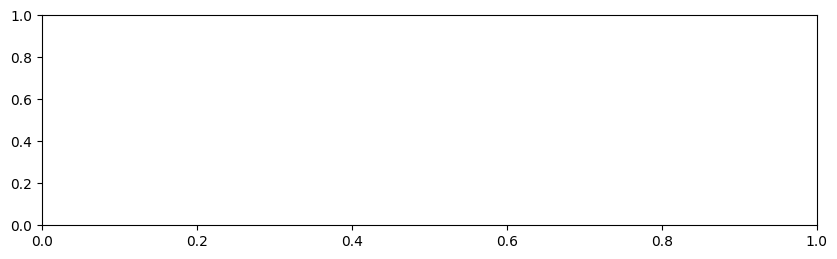

In [13]:
logging.info("Only germline data")
filtered_data = df[(~df['datasets'].str.contains('somatic'))] # Filtered dataset
plt = plot_boxplots(filtered_data, metric_name=metric_name, group_palette=predefined_palette)
savefig(plt, os.path.join(FIGDIR, f"pnet_germline_focus_{metric_name}"))
plt.show()


logging.info("Somatic and germline data, plus somatic only")
filtered_data = df[(df['datasets'].str.contains('somatic') & df['datasets'].str.contains('germline')) | (df['datasets'] == "somatic_amp somatic_del somatic_mut")] # Filtered dataset
plt = plot_boxplots(filtered_data, metric_name=metric_name, group_palette=predefined_palette)
savefig(plt, os.path.join(FIGDIR, f"pnet_somatic_focus_{metric_name}"))
plt.show()

logging.info("All data combos")
filtered_data = df
plt = plot_boxplots(filtered_data, metric_name=metric_name, group_palette=predefined_palette)
savefig(plt, os.path.join(FIGDIR, f"pnet_somatic_and_germline_{metric_name}"))
plt.show()


## Calculate Feature Importance
Calculate feature importance for the runs and generate DataFrames for top-ranked genes.

In [28]:
# Functions to Calculate Feature Importance
def calculate_feature_importance(runs, response_df):
    imps_by_key = {}
    ranks_by_key = {}

    for _index, row in runs.iterrows():
        importances_path = row['feature_importances_path']
        imps = pd.read_csv(importances_path).set_index('Unnamed: 0')
        imps = imps.join(response_df).groupby('response').mean().diff(axis=0).iloc[1]
        ranks = imps.rank(ascending=False)

        key = row['model_type'] + "_" + row['datasets']
        if key not in imps_by_key:
            imps_by_key[key] = []
            ranks_by_key[key] = []

        imps_by_key[key].append(imps)
        ranks_by_key[key].append(ranks)

    return imps_by_key, ranks_by_key

In [130]:
# Fetch the runs
def fetch_wandb_runs(project_name, sweep_id):
    api = wandb.Api()
    runs = api.runs(project_name, filters={"sweep": sweep_id, "state": "finished"})
    return runs

def fetch_feature_importance_paths(runs, group_name, who="validation"):
    # You can use this DataFrame to access the paths to the gene x modality importances files

    # Create an empty list to store DataFrames
    dfs = []
    for run in runs:
        model_type = run.config.get("model_type", "unknown")
        datasets = run.config.get("datasets", "unknown")
        subdir_name = f"{model_type}_eval_set_{who}"

        # Paths to feature and gene importances files
        feature_importances_path = f'../results/{group_name}/{subdir_name}/wandbID_{run.id}/{who}_gene_feature_importances.csv'
        gene_importances_path = f'../results/{group_name}/{subdir_name}/wandbID_{run.id}/{who}_gene_importances.csv'

        # Create a DataFrame for the current run
        df = pd.DataFrame({
            "run_id": [run.id],
            "model_type": [model_type],
            "datasets": [datasets],
            "feature_importances_path": [feature_importances_path],
            # "gene_importances_path": [gene_importances_path]
        })

        # Append the DataFrame to the list
        dfs.append(df)

    # Concatenate all DataFrames in the list into a single DataFrame
    df = pd.concat(dfs, ignore_index=True)
    df.set_index("run_id", inplace=True)

    return df


def load_feature_importances(importances_path):
    """
    Load feature importance data from a CSV file.

    Args:
        importances_path (str): Path to the feature importance file.

    Returns:
        pd.DataFrame: DataFrame of feature importances.
    """
    if not os.path.exists(importances_path):
        raise FileNotFoundError(f"File not found: {importances_path}")
    return pd.read_csv(importances_path).set_index('Unnamed: 0')


def process_importances(imps, response_df):
    """
    Process feature importances by joining with response data and calculating differences between sample classes.
    This function computes the mean feature importances for each response class and then calculates the difference between them.
    The result is a Series of feature importance differences.

    Args:
        imps (pd.DataFrame): Feature importance DataFrame.
        response_df (pd.DataFrame): Response variable DataFrame.

    Returns:
        pd.Series: Processed feature importance differences.
    """
    logger.debug(f"head of imps.join(response_df).groupby('response').mean(): {imps.join(response_df).groupby('response').mean().head()}")
    logger.debug(f"shape of imps.join(response_df).groupby('response').mean(): {imps.join(response_df).groupby('response').mean().shape}")
    return imps.join(response_df).groupby('response').mean().diff(axis=0).iloc[1]

def process_feature_importances(df_feature_importance_paths, response_df):
    """
    Process feature importance data for multiple runs and group by dataset.

    Args:
        df_feature_importance_paths (pd.DataFrame): DataFrame with feature importance paths and dataset info.
        response_df (pd.DataFrame): Response variable DataFrame.

    Returns:
        tuple: Dictionaries of DataFrames for feature importances and ranks grouped by the input datasets used in the model.
    """
    imps_by_key = {}
    ranks_by_key = {}

    for _, row in df_feature_importance_paths.iterrows():
        try:
            imps = load_feature_importances(row['feature_importances_path'])
            processed_imps = process_importances(imps, response_df)
            ranks = processed_imps.abs().rank(ascending=False)

            key = row['datasets']
            imps_by_key.setdefault(key, []).append(processed_imps)
            ranks_by_key.setdefault(key, []).append(ranks)
        except FileNotFoundError as e:
            print(e)
            continue

    df_imps_by_key = {key: pd.DataFrame(imps_list) for key, imps_list in imps_by_key.items()}
    df_ranks_by_key = {key: pd.DataFrame(ranks_list) for key, ranks_list in ranks_by_key.items()}

    return df_imps_by_key, df_ranks_by_key


def load_response_variable(response_path='../../pnet_germline/data/pnet_database/prostate/processed/response_paper.csv'):
    # Load the response variable DataFrame
    response_df = pd.read_csv(response_path)
    response_df.rename(columns={'id': "Tumor_Sample_Barcode"}, inplace=True)
    response_df.set_index('Tumor_Sample_Barcode', inplace=True)
    return response_df

def calculate_snr_for_sweep_results(df_imps_by_key):
    """
    Calculate Signal-to-Noise Ratio (SNR) for each dataset. SNR is defined as the mean divided by the standard deviation.
    This function computes the SNR for each dataset in the provided dictionary of DataFrames.
    We add a small constant to avoid division by zero.

    Args:
        df_imps_by_key (dict): Dictionary of DataFrames containing feature importances. Shape of DF is (n_runs, n_features). Each key is a dataset name.

    Returns:
        pd.DataFrame: DataFrame of SNR values for each dataset.
    """
    # TODO: I'm getting big negative numbers. Should I be looking at the absolute value of the SNR?
    # Calculate SNR for each dataset
    # SNR = mean / std
    # Adding a small constant to avoid division by zero
    dict_snr_per_key = {}
    for key, df in df_imps_by_key.items():
        snr = df.mean(axis=0) / (df.std(axis=0) + 1e-9)
        dict_snr_per_key[key] = snr.sort_values(ascending=False)

    snr_df = pd.DataFrame(dict_snr_per_key).transpose().reset_index().rename(columns={'index': 'key'})
    return dict_snr_per_key, snr_df


def extract_top_features_from_df(df_per_dataset, top_n=10, keep_smallest_n=True, index_label=None):
    """
    Extract the top N features by rank for each dataset.

    Args:
        df_per_dataset (dict): Dictionary containing feature-level pd DataFrames for each dataset.
        top_n (int): Number of top features to extract.
        keep_smallest_n (bool): Whether to sort in ascending order (lower rank is better).

    Returns:
        pd.DataFrame: DataFrame containing the top N features for each dataset.
    """
    top_features_df = pd.DataFrame()

    # Iterate over the dictionary to calculate top features
    for dataset, df in df_per_dataset.items():
        # Calculate the mean rank for each feature and select the top N
        top_features = df.mean(axis=0).sort_values(ascending=keep_smallest_n)[:top_n]
        # Add the top features as a column to the DataFrame
        top_features_df[dataset] = top_features.index

    # Set the index of the DataFrame to be 1 through top_n
    top_features_df.index = range(1, top_n + 1)

    if index_label is not None:
        top_features_df.index.name = index_label

    return top_features_df

def extract_top_features_from_series(series_per_dataset, top_n=10, keep_smallest_n=True, index_label=None):
    """
    Extract the top N features by rank for each dataset.

    Args:
        series_per_dataset (dict): Dictionary containing feature-level pd Series for each dataset.
        top_n (int): Number of top features to extract.
        keep_smallest_n (bool): Whether to sort in ascending order (lower rank is better).

    Returns:
        pd.DataFrame: DataFrame containing the top N features for each dataset.
    """
    top_features_df = pd.DataFrame()

    # Iterate over the dictionary to calculate top features
    for dataset, values in series_per_dataset.items():
        # Calculate the mean rank for each feature and select the top N
        top_features = values.sort_values(ascending=keep_smallest_n)[:top_n]
        # Add the top features as a column to the DataFrame
        top_features_df[dataset] = top_features.index

    # Set the index of the DataFrame to be 1 through top_n
    top_features_df.index = range(1, top_n + 1)

    if index_label is not None:
        top_features_df.index.name = index_label

    return top_features_df

In [ ]:
logger.info("Get information on the sweep runs")
MODEL_TYPE = "pnet"
runs = fetch_wandb_runs(PROJECT_NAME, SWEEP_ID)
df_feature_importance_paths = fetch_feature_importance_paths(runs, GROUP_NAME)
logger.info(f"Filter to runs where model_type is {MODEL_TYPE}")
df_feature_importance_paths = df_feature_importance_paths[df_feature_importance_paths['model_type'] == MODEL_TYPE]
df_feature_importance_paths.head()

logger.info("Get the feature importances and ranks for each dataset combination")
response_df = load_response_variable()
df_imps_by_key, df_ranks_by_key = process_feature_importances(df_feature_importance_paths, response_df)

logger.info("Example df_imps_by_key DF:")
df_imps_by_key['somatic_amp somatic_del somatic_mut']

2025-05-02 05:08:35 INFO     [__main__] Get information on the sweep runs
2025-05-02 05:08:35 INFO     [__main__] Filter to runs where model_type is pnet
2025-05-02 05:08:35 INFO     [__main__] Get the feature importances and ranks for each dataset combination


File not found: ../results/pnet_somatic_and_germline_exp_004/pnet_eval_set_validation/wandbID_c8a10m4g/validation_gene_feature_importances.csv
File not found: ../results/pnet_somatic_and_germline_exp_004/pnet_eval_set_validation/wandbID_gpi5ej9q/validation_gene_feature_importances.csv
File not found: ../results/pnet_somatic_and_germline_exp_004/pnet_eval_set_validation/wandbID_ydvqg2tn/validation_gene_feature_importances.csv
File not found: ../results/pnet_somatic_and_germline_exp_004/pnet_eval_set_validation/wandbID_qup180f6/validation_gene_feature_importances.csv


2025-05-02 05:08:50 INFO     [__main__] Example df_imps_by_key DF:


,TAS2R16_somatic_amp,CTNNBIP1_somatic_amp,TXNDC15_somatic_amp,PIK3C2B_somatic_amp,NRSN1_somatic_amp,SP3_somatic_amp,MURC_somatic_amp,GNB2L1_somatic_amp,GLT6D1_somatic_amp,ZNF621_somatic_amp,...,MRPS22_somatic_mut,SPDYA_somatic_mut,OMD_somatic_mut,ESRRA_somatic_mut,TTC39A_somatic_mut,KCND2_somatic_mut,PAX6_somatic_mut,LCE2B_somatic_mut,LRP8_somatic_mut,ANAPC2_somatic_mut
1,0.000413,0.000009,0.0,-0.002351,0.0,0.0,0.001695,-0.000145,6.450082e-05,0.0,...,-0.001358,0.0,0.0,0.0,0.0,-0.000481,0.0,-0.000145,0.0,0.0
1,0.001090,-0.000157,0.0,0.002724,0.0,0.0,0.000022,0.001542,-1.363590e-07,0.0,...,-0.000083,0.0,0.0,0.0,0.0,-0.006571,0.0,-0.002036,0.0,0.0
1,0.000950,-0.000411,0.0,-0.001911,0.0,0.0,0.000600,0.001593,-2.693340e-04,0.0,...,-0.006651,0.0,0.0,0.0,0.0,-0.002311,0.0,-0.001852,0.0,0.0
1,-0.000098,-0.000037,0.0,0.001266,0.0,0.0,0.000608,0.000759,5.186137e-05,0.0,...,-0.000568,0.0,0.0,0.0,0.0,-0.000321,0.0,-0.003703,0.0,0.0


## Top-Ranked Gene Importance Scores
Extract the top-ranked gene importance scores for each dataset and store them in a DataFrame.

In [ ]:
print("Top features by P-NET model rank:")
top_10_features_by_rank = extract_top_features_from_df(df_ranks_by_key, top_n=10, keep_smallest_n=True, index_label="rank")
display(top_10_features_by_rank)

Top features by P-NET model rank:


,somatic_amp somatic_del somatic_mut germline_rare_common_missense,germline_rare_common_lof_missense,germline_common_lof_missense,germline_rare_lof_missense,germline_rare_common_missense,somatic_amp somatic_del somatic_mut,somatic_amp somatic_del somatic_mut germline_rare_common_lof,germline_rare_lof
rank,,,,,,,,
1,AR_somatic_amp,BRCA2_germline_rare_common_lof_missense,CPT2_germline_common_lof_missense,BRCA2_germline_rare_lof_missense,APC_germline_rare_common_missense,AR_somatic_amp,AR_somatic_amp,BRCA2_germline_rare_lof
2,AR_somatic_mut,HLA-A_germline_rare_common_lof_missense,PLAGL1_germline_common_lof_missense,HLA-A_germline_rare_lof_missense,MITF_germline_rare_common_missense,AR_somatic_mut,AR_somatic_mut,HLA-A_germline_rare_lof
3,TP53_somatic_mut,SBDS_germline_rare_common_lof_missense,HOXD13_germline_common_lof_missense,WNK2_germline_rare_lof_missense,MUTYH_germline_rare_common_missense,TP53_somatic_mut,TP53_somatic_mut,SBDS_germline_rare_lof
4,PTEN_somatic_del,WNK2_germline_rare_common_lof_missense,PGAP2_germline_common_lof_missense,SBDS_germline_rare_lof_missense,HNF1A_germline_rare_common_missense,PTEN_somatic_del,PTEN_somatic_del,ATM_germline_rare_lof
5,APC_somatic_mut,PMS2_germline_rare_common_lof_missense,BMP5_germline_common_lof_missense,ATM_germline_rare_lof_missense,TNC_germline_rare_common_missense,APC_somatic_mut,RBBP5_somatic_amp,WNK2_germline_rare_lof
6,GNAS_somatic_mut,ATM_germline_rare_common_lof_missense,GBGT1_germline_common_lof_missense,PMS2_germline_rare_lof_missense,B3GAT3_germline_rare_common_missense,GNAS_somatic_mut,GNAS_somatic_mut,PMS2_germline_rare_lof
7,RBBP5_somatic_amp,PMS1_germline_rare_common_lof_missense,CAPN1_germline_common_lof_missense,APC_germline_rare_lof_missense,MGLL_germline_rare_common_missense,RAC1_somatic_amp,MUC4_somatic_mut,PMS1_germline_rare_lof
8,OBSCN_somatic_del,CNBD1_germline_rare_common_lof_missense,TOP2B_germline_common_lof_missense,PMS1_germline_rare_lof_missense,CLDN15_germline_rare_common_missense,OBSCN_somatic_del,MAML3_somatic_del,ABL2_germline_rare_lof
9,MDM4_somatic_amp,APC_germline_rare_common_lof_missense,TRIM11_germline_common_lof_missense,CNBD1_germline_rare_lof_missense,BNIP3_germline_rare_common_missense,MAML3_somatic_del,RAC1_somatic_amp,CNBD1_germline_rare_lof


In [158]:
# Extract the top-ranked genes by importance for each dataset
for dataset, data in df_imps_by_key.items():
    top_genes = data.mean(axis=0).nlargest(10)
    top_genes.index = top_genes.index.str.split('_').str[0]
    print(f"Top genes for {dataset}:")
    print(top_genes)
    print("\n")

Top genes for somatic_amp somatic_del somatic_mut germline_rare_common_missense:
AR        1.149205
AR        0.402249
TP53      0.273925
PTEN      0.101653
APC       0.074284
MUC4      0.057127
RBBP5     0.054564
GNAS      0.050764
COL1A2    0.042054
OBSCN     0.038580
dtype: float64


Top genes for germline_rare_common_lof_missense:
BRCA2    0.017394
WNK2     0.006644
SBDS     0.005581
HLA-A    0.004884
PMS2     0.002835
AKAP9    0.001722
PMS1     0.001334
AGL      0.000386
APC      0.000322
MITF     0.000184
dtype: float64


Top genes for germline_common_lof_missense:
CPT2      0.0
RBM15B    0.0
STK31     0.0
MRPL3     0.0
GBE1      0.0
PIK3R1    0.0
TMEM9B    0.0
FBXW5     0.0
GLUD1     0.0
PREX2     0.0
dtype: float64


Top genes for germline_rare_lof_missense:
BRCA2    0.015446
HLA-A    0.004853
WNK2     0.004702
SBDS     0.004262
PMS2     0.001621
PMS1     0.001421
APC      0.001131
AKAP9    0.000715
MPL      0.000192
HNF1A    0.000159
dtype: float64


Top genes for germline_rar

In [93]:
def report_mean_importance(features, df_imps_by_dataset):
    """
    Report the mean importance of specific features across each dataset, keeping the column order as input.

    Args:
        features (list): List of feature names to report.
        df_imps_by_dataset (dict): Dictionary of DataFrames containing feature importances for each dataset.

    Returns:
        pd.DataFrame: DataFrame with the mean importance of the specified features for each dataset.
    """
    mean_importance_df = pd.DataFrame()

    # Iterate over the datasets in df_imps_by_dataset
    for dataset, df in df_imps_by_dataset.items():
        # Filter the DataFrame to include only the specified features
        filtered_df = df.loc[:, df.columns.isin(features)]
        # Calculate the mean importance for the filtered features
        mean_importance = filtered_df.mean(axis=0)
        # Add the mean importance as a column to the result DataFrame
        mean_importance_df[dataset] = mean_importance

    # Transpose the result for better readability
    return mean_importance_df.transpose()

# Example usage
features_to_extract = top_10_features_by_rank['somatic_amp somatic_del somatic_mut'][:10].values.tolist()
mean_importance_report = report_mean_importance(features_to_extract, df_imps_by_key)
print("Mean importance of selected features across datasets:")
display(mean_importance_report)

Mean importance of selected features across datasets:


,RAC1_somatic_amp,AR_somatic_amp,PTEN_somatic_del,MAML3_somatic_del,OBSCN_somatic_del,TP53_somatic_mut,GNAS_somatic_mut,MUC4_somatic_mut,AR_somatic_mut,APC_somatic_mut
somatic_amp somatic_del somatic_mut germline_rare_common_missense,0.035308,1.149205,0.101653,0.038275,0.038580,0.273925,0.050764,0.057127,0.402249,0.074284
germline_rare_common_lof_missense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
germline_common_lof_missense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
germline_rare_lof_missense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
germline_rare_common_missense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
somatic_amp somatic_del somatic_mut,0.036818,1.046422,0.086838,0.037276,0.035283,0.242947,0.050568,0.050201,0.337128,0.074513
somatic_amp somatic_del somatic_mut germline_rare_common_lof,0.057452,0.994685,0.094174,0.054158,0.045239,0.289129,0.063785,0.063567,0.350767,0.018726
germline_rare_lof,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Top-Ranked Genes by SNR Calculation
Calculate the Signal-to-Noise Ratio (SNR) for each gene and extract the top-ranked genes by SNR. Store the results in a DataFrame.

NOTE: can choose to look at features with the most positive, most negative, or highest magnitude SNR values. Each has different interpretations.

In [140]:
logger.info("Calculate SNR for each dataset")
dict_snr_per_key, snr_df = calculate_snr_for_sweep_results(df_imps_by_key)

2025-05-02 05:57:57 INFO     [__main__] Calculate SNR for each dataset


In [141]:
most_positive_snr_features = extract_top_features_from_series(dict_snr_per_key, top_n=10, keep_smallest_n=False, index_label="most positive SNRs")
most_positive_snr_features

,somatic_amp somatic_del somatic_mut germline_rare_common_missense,germline_rare_common_lof_missense,germline_common_lof_missense,germline_rare_lof_missense,germline_rare_common_missense,somatic_amp somatic_del somatic_mut,somatic_amp somatic_del somatic_mut germline_rare_common_lof,germline_rare_lof
most positive SNRs,,,,,,,,
1,AR_somatic_amp,PMS2_germline_rare_common_lof_missense,CPT2_germline_common_lof_missense,BRCA2_germline_rare_lof_missense,APC_germline_rare_common_missense,RAC1_somatic_amp,GNPDA1_somatic_amp,PMS2_germline_rare_lof
2,AR_somatic_mut,BRCA2_germline_rare_common_lof_missense,RAB14_germline_common_lof_missense,PMS2_germline_rare_lof_missense,MITF_germline_rare_common_missense,WWTR1_somatic_amp,KLHL2_somatic_mut,HLA-A_germline_rare_lof
3,MDM4_somatic_amp,WNK2_germline_rare_common_lof_missense,MRPL3_germline_common_lof_missense,HLA-A_germline_rare_lof_missense,HNF1A_germline_rare_common_missense,OBSCN_somatic_del,EPHA1_somatic_amp,BRCA2_germline_rare_lof
4,OBSCN_somatic_del,SBDS_germline_rare_common_lof_missense,GBE1_germline_common_lof_missense,PMS1_germline_rare_lof_missense,FAM69B_germline_rare_common_missense,MGAM_somatic_del,FNDC7_somatic_mut,WNK2_germline_rare_lof
5,GRM2_somatic_mut,AKAP9_germline_rare_common_lof_missense,PIK3R1_germline_common_lof_missense,AKAP9_germline_rare_lof_missense,PGBD5_germline_rare_common_missense,PPFIBP2_somatic_mut,GALE_somatic_del,AKAP9_germline_rare_lof
6,TADA1_somatic_del,AGL_germline_rare_common_lof_missense,TMEM9B_germline_common_lof_missense,WNK2_germline_rare_lof_missense,CARS_germline_rare_common_missense,ZEB1_somatic_amp,SEC24C_somatic_amp,SBDS_germline_rare_lof
7,DDO_somatic_del,PDCD1LG2_germline_rare_common_lof_missense,FBXW5_germline_common_lof_missense,HNF1A_germline_rare_lof_missense,TMED7_germline_rare_common_missense,RGS20_somatic_mut,ROS1_somatic_mut,PMS1_germline_rare_lof
8,TP53_somatic_mut,PMS1_germline_rare_common_lof_missense,GLUD1_germline_common_lof_missense,SBDS_germline_rare_lof_missense,STK32B_germline_rare_common_missense,CDK5_somatic_del,NF1_somatic_mut,PDCD1LG2_germline_rare_lof
9,APC_germline_rare_common_missense,HLA-A_germline_rare_common_lof_missense,PREX2_germline_common_lof_missense,AGL_germline_rare_lof_missense,SNAPC3_germline_rare_common_missense,GNA14_somatic_del,INO80B_somatic_amp,MPL_germline_rare_lof


In [142]:
most_negative_snr_features = extract_top_features_from_series(dict_snr_per_key, top_n=10, keep_smallest_n=True, index_label="most negative SNRs")
most_negative_snr_features

,somatic_amp somatic_del somatic_mut germline_rare_common_missense,germline_rare_common_lof_missense,germline_common_lof_missense,germline_rare_lof_missense,germline_rare_common_missense,somatic_amp somatic_del somatic_mut,somatic_amp somatic_del somatic_mut germline_rare_common_lof,germline_rare_lof
most negative SNRs,,,,,,,,
1,XPO1_somatic_del,PDE4DIP_germline_rare_common_lof_missense,CPT2_germline_common_lof_missense,ATM_germline_rare_lof_missense,MUTYH_germline_rare_common_missense,RUNX1_somatic_del,TFRC_somatic_del,ATM_germline_rare_lof
2,VCL_somatic_del,CNBD1_germline_rare_common_lof_missense,GBE1_germline_common_lof_missense,PDE4DIP_germline_rare_lof_missense,TNC_germline_rare_common_missense,CASP1_somatic_del,S1PR1_somatic_del,CNBD1_germline_rare_lof
3,EPB41L2_somatic_del,ATM_germline_rare_common_lof_missense,PIK3R1_germline_common_lof_missense,CNBD1_germline_rare_lof_missense,CNBP_germline_rare_common_missense,BRD9_somatic_mut,DLAT_somatic_del,ABL2_germline_rare_lof
4,CASP1_somatic_del,ABL2_germline_rare_common_lof_missense,TMEM9B_germline_common_lof_missense,UROD_germline_rare_lof_missense,TMED7_germline_rare_common_missense,NRG1_somatic_amp,NCL_somatic_amp,PDE4DIP_germline_rare_lof
5,SEC24C_somatic_del,UROD_germline_rare_common_lof_missense,FBXW5_germline_common_lof_missense,MUTYH_germline_rare_lof_missense,STK32B_germline_rare_common_missense,SUSD4_somatic_amp,LCK_somatic_del,UROD_germline_rare_lof
6,SEC16A_somatic_amp,HNF1A_germline_rare_common_lof_missense,GLUD1_germline_common_lof_missense,BARD1_germline_rare_lof_missense,SNAPC3_germline_rare_common_missense,PTEN_somatic_mut,PARD3_somatic_amp,BARD1_germline_rare_lof
7,ABCB6_somatic_amp,THRAP3_germline_rare_common_lof_missense,PREX2_germline_common_lof_missense,EML4_germline_rare_lof_missense,POLL_germline_rare_common_missense,ZEB1_somatic_mut,FAM175A_somatic_amp,THRAP3_germline_rare_lof
8,ST3GAL6_somatic_del,EWSR1_germline_rare_common_lof_missense,MRPL3_germline_common_lof_missense,THRAP3_germline_rare_lof_missense,TMEM207_germline_rare_common_missense,PADI3_somatic_del,RPS27A_somatic_amp,ASNSD1_germline_rare_lof
9,ITGA6_somatic_mut,TNC_germline_rare_common_lof_missense,HK1_germline_common_lof_missense,SFRP4_germline_rare_lof_missense,WDR64_germline_rare_common_missense,PPFIA1_somatic_del,GIMAP1_somatic_del,TEX12_germline_rare_lof


In [149]:
dict_snr_per_key['somatic_amp somatic_del somatic_mut germline_rare_common_missense'].abs().sort_values(ascending=False).head(10)

AR_somatic_amp       12.571767
AR_somatic_mut       11.467164
MDM4_somatic_amp     10.143745
XPO1_somatic_del      8.980731
OBSCN_somatic_del     8.010046
GRM2_somatic_mut      7.776100
TADA1_somatic_del     6.937431
DDO_somatic_del       6.912855
TP53_somatic_mut      6.745793
VCL_somatic_del       6.704737
dtype: float64

In [151]:
# Extract the top-ranked genes by SNR for each dataset
for dataset, snr_series in dict_snr_per_key.items():
    top_genes = snr_series.nlargest(10)
    top_genes.index = top_genes.index.str.split('_').str[0]
    print(f"Top genes for {dataset}:")
    print(top_genes)
    print("\n")

Top genes for somatic_amp somatic_del somatic_mut germline_rare_common_missense:
AR        12.571767
AR        11.467164
MDM4      10.143745
OBSCN      8.010046
GRM2       7.776100
TADA1      6.937431
DDO        6.912855
TP53       6.745793
APC        6.366013
SEC24C     5.469341
dtype: float64


Top genes for germline_rare_common_lof_missense:
PMS2        4.819013
BRCA2       2.470068
WNK2        1.487294
SBDS        1.198165
AKAP9       0.888350
AGL         0.801210
PDCD1LG2    0.736981
PMS1        0.662756
HLA-A       0.625361
ECT2L       0.497952
dtype: float64


Top genes for germline_common_lof_missense:
CPT2      0.0
KLF6      0.0
TOP2B     0.0
PLAGL1    0.0
HOXD13    0.0
PGAP2     0.0
BMP5      0.0
GBGT1     0.0
CAPN1     0.0
TRIM11    0.0
dtype: float64


Top genes for germline_rare_lof_missense:
BRCA2    2.202499
PMS2     1.644533
HLA-A    1.169129
PMS1     1.166144
AKAP9    1.094123
WNK2     1.015736
HNF1A    0.916967
SBDS     0.904148
AGL      0.777060
MPL      0.572683
dty